In [184]:
import pandas as pd
import numpy as np

In [185]:
sales=pd.read_csv('sales.csv')
sales.head()

,Order_ID,Date,Product_ID,Quantity_Sold,Unit_Price
0,O73274,2024-01-01,P001,20,7.92
1,O13465,2024-01-02,P001,16,11.17
2,O11070,2024-01-03,P001,14,6.99
3,O87377,2024-01-04,P001,17,19.54
4,O20594,2024-01-05,P001,5,16.16


In [186]:
products=pd.read_csv('products.csv')
products.head()

,Product_ID,Product_Name,Category,Warehouse_ID,Stock_Level,Reorder_Point,Reorder_Quantity,Safety_Stock,Holding_Cost,Supplier_ID
0,P001,Product_1,Fruits,W3,819,153,144,132,0.69,S008
1,P002,Product_2,Dairy,W2,848,263,161,21,0.21,S002
2,P003,Product_3,Grains,W3,437,268,233,149,0.28,S006
3,P004,Product_4,Fruits,W3,978,84,383,73,0.73,S007
4,P005,Product_5,Fruits,W1,152,242,127,106,0.20,S002


In [187]:
suppliers=pd.read_csv('suppliers.csv')
suppliers.head()

,Supplier_ID,Supplier_Name,Location
0,S001,Supplier_1,Delta
1,S002,Supplier_2,Giza
2,S003,Supplier_3,Cairo
3,S004,Supplier_4,Giza
4,S005,Supplier_5,Alex


In [188]:
procurement=pd.read_csv('procurement.csv')
procurement.head()

,PO_ID,Product_ID,Supplier_ID,Order_Date,Delivery_Date,Quantity_Ordered,Quantity_Received,Cost,Defect_Rate
0,PO5925,P001,S008,2024-06-22,2024-06-24,208,196,3045.93,0.047
1,PO5560,P001,S008,2024-03-19,2024-03-25,134,118,1957.18,0.041
2,PO5022,P001,S008,2024-01-26,2024-02-04,387,376,4950.57,0.042
3,PO6849,P001,S008,2024-05-21,2024-05-30,202,186,2465.17,0.007
4,PO6124,P001,S008,2024-02-19,2024-02-27,399,387,4284.67,0.049


In [189]:
sales["Date"] = pd.to_datetime(sales["Date"])

### Demand Analysis

In [190]:
daily_demand = sales.groupby("Date")["Quantity_Sold"].sum().reset_index()
daily_demand.head()

,Date,Quantity_Sold
0,2024-01-01,1483
1,2024-01-02,1766
2,2024-01-03,1884
3,2024-01-04,1634
4,2024-01-05,1230


In [191]:
monthly_demand = sales.groupby(pd.Grouper(key="Date", freq="MS"))["Quantity_Sold"].sum().reset_index()
monthly_demand.head()

,Date,Quantity_Sold
0,2024-01-01,45270
1,2024-02-01,41622
2,2024-03-01,43506
3,2024-04-01,42997
4,2024-05-01,44697


In [192]:
sales['Month'] = sales['Date'].dt.to_period('M')
monthly_demand = sales.groupby('Month')["Quantity_Sold"].sum().reset_index()
monthly_demand.head()

,Month,Quantity_Sold
0,2024-01,45270
1,2024-02,41622
2,2024-03,43506
3,2024-04,42997
4,2024-05,44697


In [193]:
### Moving Average
daily_demand["MA_7"] = daily_demand["Quantity_Sold"].rolling(window=7).mean()
daily_demand["MA_30"] = daily_demand["Quantity_Sold"].rolling(window=30).mean()

In [194]:
### Demand Variability
daily_demand["STD_7"] = daily_demand["Quantity_Sold"].rolling(window=7).std()

In [195]:
daily_demand["Day_of_Week"] = daily_demand["Date"].dt.day_name()

weekly_pattern = daily_demand.groupby("Day_of_Week")["Quantity_Sold"].mean()
print(weekly_pattern)

Day_of_Week
Friday       1244.192308
Monday       1425.461538
Saturday     1006.320000
Sunday       1091.400000
Thursday     1628.153846
Tuesday      1762.000000
Wednesday    1842.076923
Name: Quantity_Sold, dtype: float64


In [196]:
daily_demand.tail()

,Date,Quantity_Sold,MA_7,MA_30,STD_7,Day_of_Week
175,2024-06-24,1380,1425.142857,1418.200000,339.020859,Monday
176,2024-06-25,1725,1417.142857,1437.766667,329.758209,Tuesday
177,2024-06-26,1793,1404.857143,1449.933333,310.736452,Wednesday
178,2024-06-27,1584,1401.857143,1443.366667,308.575992,Thursday
179,2024-06-28,1256,1404.428571,1423.133333,307.054206,Friday


### Exploratory Data Analysis (EDA)

In [197]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       9000 non-null   object        
 1   Date           9000 non-null   datetime64[ns]
 2   Product_ID     9000 non-null   object        
 3   Quantity_Sold  9000 non-null   int64         
 4   Unit_Price     9000 non-null   float64       
 5   Month          9000 non-null   period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(2), period[M](1)
memory usage: 422.0+ KB


In [198]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_ID        50 non-null     object 
 1   Product_Name      50 non-null     object 
 2   Category          50 non-null     object 
 3   Warehouse_ID      50 non-null     object 
 4   Stock_Level       50 non-null     int64  
 5   Reorder_Point     50 non-null     int64  
 6   Reorder_Quantity  50 non-null     int64  
 7   Safety_Stock      50 non-null     int64  
 8   Holding_Cost      50 non-null     float64
 9   Supplier_ID       50 non-null     object 
dtypes: float64(1), int64(4), object(5)
memory usage: 4.0+ KB


In [199]:
sales.isna().sum()

Order_ID         0
Date             0
Product_ID       0
Quantity_Sold    0
Unit_Price       0
Month            0
dtype: int64

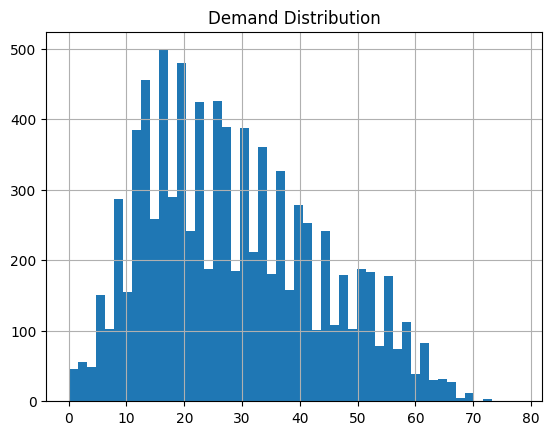

In [200]:
import matplotlib.pyplot as plt

sales["Quantity_Sold"].hist(bins=50)
plt.title("Demand Distribution")
plt.show()

<Axes: title={'center': 'Daily Demand'}, xlabel='Date'>

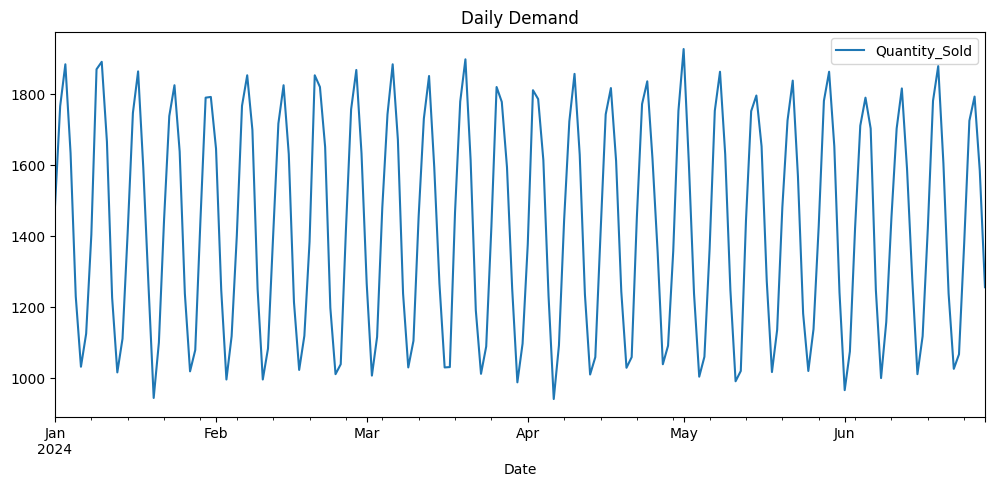

In [201]:
daily_demand.plot(x="Date", y="Quantity_Sold", figsize=(12,5), title="Daily Demand")

In [202]:
top_products = sales.groupby("Product_ID")["Quantity_Sold"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product_ID
P015    8816
P006    8587
P016    8512
P026    8320
P041    8295
P012    8217
P013    8153
P035    8057
P037    7964
P010    7874
Name: Quantity_Sold, dtype: int64


In [203]:
sales["Day"] = sales["Date"].dt.day_name()
sales.groupby("Day")["Quantity_Sold"].mean().sort_values()

Day
Saturday     20.126400
Sunday       21.828000
Friday       24.883846
Monday       28.509231
Thursday     32.563077
Tuesday      35.240000
Wednesday    36.841538
Name: Quantity_Sold, dtype: float64

In [204]:
products.describe()

,Stock_Level,Reorder_Point,Reorder_Quantity,Safety_Stock,Holding_Cost
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,525.440000,183.620000,310.940000,98.100000,0.613200
std,287.346563,77.748913,106.616308,40.612781,0.240335
min,114.000000,50.000000,127.000000,21.000000,0.200000
25%,242.500000,116.250000,216.250000,68.000000,0.412500
50%,512.000000,188.500000,310.500000,109.000000,0.645000
75%,810.000000,255.750000,403.000000,132.000000,0.795000
max,978.000000,296.000000,486.000000,149.000000,0.980000


#### We measure variability using the Coefficient of Variation (CV) to Determine whether demand is stable or volatile.
#### CV < 0.5 → Stable Demand 
#### CV > 1 → Volatile Demand 

In [205]:
cv = sales.groupby("Product_ID")["Quantity_Sold"].agg(["mean", "std"])
cv["CV"] = cv["std"] / cv["mean"]
cv["CV"].head(10)

Product_ID
P001    0.445213
P002    0.353043
P003    0.264587
P004    0.285084
P005    0.239137
P006    0.221604
P007    0.249832
P008    0.443353
P009    0.265068
P010    0.240100
Name: CV, dtype: float64

### Mismatch Analysis
#### Significant mismatches were observed between inventory levels and actual demand, indicating risks of both stockouts and overstock situations.

In [206]:
merged = sales.groupby("Product_ID")["Quantity_Sold"].sum().reset_index()
merged = merged.merge(products[["Product_ID", "Stock_Level"]], on="Product_ID")
merged["Mismatch"] = merged["Stock_Level"] - merged["Quantity_Sold"]
print(merged.describe())

       Quantity_Sold  Stock_Level    Mismatch
count      50.000000    50.000000    50.00000
mean     5157.840000   525.440000 -4632.40000
std      2268.989457   287.346563  2299.12206
min      1938.000000   114.000000 -8348.00000
25%      2973.000000   242.500000 -6867.50000
50%      4852.500000   512.000000 -4534.00000
75%      7400.500000   810.000000 -2555.50000
max      8816.000000   978.000000 -1264.00000


### Reorder Point Optimization

In [208]:
avg_demand = sales.groupby("Product_ID")["Quantity_Sold"].mean().reset_index()
avg_demand.columns = ["Product_ID", "Avg_Demand"]

In [209]:
df = products.merge(avg_demand, on="Product_ID")

In [210]:
df["ROP"] = (df["Avg_Demand"] * df["Lead_Time"]) + df["Safety_Stock"]
df[["Product_ID", "Avg_Demand", "Lead_Time", "ROP"]].head()

,Product_ID,Avg_Demand,Lead_Time,ROP
0,P001,13.494444,6,212.966667
1,P002,18.938889,5,115.694444
2,P003,29.488889,2,207.977778
3,P004,23.438889,9,283.950000
4,P005,42.483333,4,275.933333


In [211]:
df["Stockout_Risk"] = df["Stock_Level"] <= df["ROP"]
df["Stockout_Risk"].value_counts()

Stockout_Risk
False    38
True     12
Name: count, dtype: int64

In [212]:
df["Safety_Stock"] = 1.65 * sales.groupby("Product_ID")["Quantity_Sold"].std().values

### Supplier Performance Evaluation

In [213]:
procurement = procurement.copy()

procurement["Lead_Time"] = (
    pd.to_datetime(procurement["Delivery_Date"]) -  pd.to_datetime(procurement["Order_Date"])).dt.days
procurement.head()

,PO_ID,Product_ID,Supplier_ID,Order_Date,Delivery_Date,Quantity_Ordered,Quantity_Received,Cost,Defect_Rate,Lead_Time
0,PO5925,P001,S008,2024-06-22,2024-06-24,208,196,3045.93,0.047,2
1,PO5560,P001,S008,2024-03-19,2024-03-25,134,118,1957.18,0.041,6
2,PO5022,P001,S008,2024-01-26,2024-02-04,387,376,4950.57,0.042,9
3,PO6849,P001,S008,2024-05-21,2024-05-30,202,186,2465.17,0.007,9
4,PO6124,P001,S008,2024-02-19,2024-02-27,399,387,4284.67,0.049,8


In [214]:
supplier_kpis = procurement.groupby("Supplier_ID").agg({
    "Lead_Time": "mean",
    "Cost": "mean",
    "Defect_Rate": "mean",
    "Quantity_Received": "sum"
}).reset_index()

supplier_kpis.rename(columns={
    "Lead_Time": "Avg_Lead_Time",
    "Cost": "Avg_Cost",
    "Defect_Rate": "Avg_Defect_Rate"
}, inplace=True)

supplier_kpis.head()

,Supplier_ID,Avg_Lead_Time,Avg_Cost,Avg_Defect_Rate,Quantity_Received
0,S001,5.620000,3332.491200,0.027440,13806
1,S002,6.483333,3106.812167,0.026083,16192
2,S003,5.800000,3814.282667,0.028133,9559
3,S004,5.700000,3080.273333,0.023700,8075
4,S005,6.350000,3345.542500,0.024150,5652


In [215]:
### On-Time Delivery Rate
procurement["On_Time"] = procurement["Lead_Time"] <= 5
on_time = procurement.groupby("Supplier_ID")["On_Time"].mean().reset_index()
on_time.columns = ["Supplier_ID", "On_Time_Rate"]
supplier_kpis = supplier_kpis.merge(on_time, on="Supplier_ID")

In [216]:
### Supplier Score
supplier_kpis["Score"] = (
    (1 / supplier_kpis["Avg_Lead_Time"]) * 0.3 +
    (1 / supplier_kpis["Avg_Cost"]) * 0.3 +
    (1 - supplier_kpis["Avg_Defect_Rate"]) * 0.2 +
    supplier_kpis["On_Time_Rate"] * 0.2
)

#### Supplier performance was evaluated using a composite scoring system based on lead time, cost efficiency, defect rate, and on-time delivery.
#### Significant variation was observed across suppliers, highlighting opportunities for strategic sourcing and supplier consolidation.
#### Certain suppliers exhibited high lead times and defect rates, indicating potential supply chain risks.

In [217]:
top_suppliers = supplier_kpis.sort_values("Score", ascending=False)
top_suppliers.head()

,Supplier_ID,Avg_Lead_Time,Avg_Cost,Avg_Defect_Rate,Quantity_Received,On_Time_Rate,Score
9,S010,5.777778,3625.535667,0.029400,27784,0.511111,0.348348
0,S001,5.620000,3332.491200,0.027440,13806,0.500000,0.347983
2,S003,5.800000,3814.282667,0.028133,9559,0.500000,0.346176
3,S004,5.700000,3080.273333,0.023700,8075,0.466667,0.341322
6,S007,6.050000,3326.916333,0.027100,16348,0.466667,0.337590


In [218]:
### Supplier Segmentation
supplier_kpis["Segment"] = pd.qcut(
    supplier_kpis["Score"] , q=3 , labels=["Low", "Medium", "High"]
)
supplier_kpis[["Supplier_ID", "Score", "Segment"]]

,Supplier_ID,Score,Segment
0,S001,0.347983,High
1,S002,0.307819,Low
2,S003,0.346176,High
3,S004,0.341322,Medium
4,S005,0.312504,Low
5,S006,0.335472,Low
6,S007,0.337590,Medium
7,S008,0.326221,Low
8,S009,0.336817,Medium
9,S010,0.348348,High


### Demand Forecasting (ARIMA + Prophet)

#### Demand forecasting models (ARIMA and Prophet) were implemented to predict future sales trends and support inventory planning decisions.
#### Prophet model effectively captured seasonality and trend components, providing more robust predictions for operational planning.
#### Forecasted demand enabled proactive inventory optimization and reduced stockout risk.

In [219]:
import pandas as pd

sales = pd.read_csv("sales.csv")
sales["Date"] = pd.to_datetime(sales["Date"])

daily = sales.groupby("Date")["Quantity_Sold"].sum().reset_index()
daily.columns = ["ds", "y"]

daily.head()

,ds,y
0,2024-01-01,1483
1,2024-01-02,1766
2,2024-01-03,1884
3,2024-01-04,1634
4,2024-01-05,1230


In [220]:
### ARIMA Forecasting
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily["y"], order=(5,1,0))
model_fit = model.fit()

forecast_arima = model_fit.forecast(steps=30)
print(forecast_arima)

180    1011.864222
181    1081.154618
182    1396.394402
183    1703.659491
184    1793.413697
185    1593.401358
186    1241.899478
187    1020.927848
188    1089.060648
189    1389.655716
190    1704.537991
191    1793.009900
192    1585.636036
193    1245.422985
194    1025.270511
195    1089.458906
196    1392.193745
197    1703.117352
198    1787.500329
199    1584.594424
200    1246.300372
201    1027.406621
202    1093.478009
203    1393.179262
204    1700.320962
205    1784.488578
206    1582.276042
207    1246.642528
208    1030.881400
209    1096.672386
Name: predicted_mean, dtype: float64


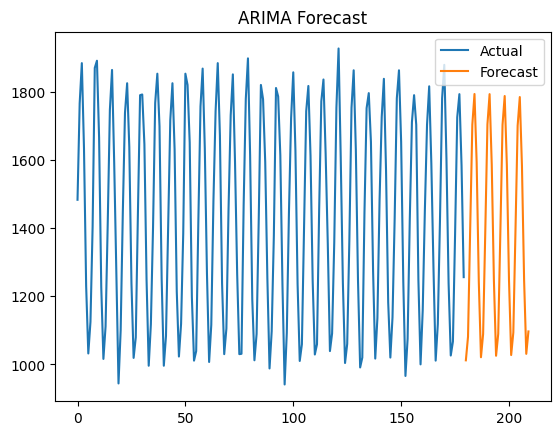

In [221]:
import matplotlib.pyplot as plt

plt.plot(daily["y"], label="Actual")
plt.plot(range(len(daily), len(daily)+30), forecast_arima, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [222]:
### Prophet Forecasting
from prophet import Prophet

model = Prophet()
model.fit(daily)

21:57:01 - cmdstanpy - INFO - Chain [1] start processing
21:57:02 - cmdstanpy - INFO - Chain [1] done processing


In [223]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
205,2024-07-24,1834.890969,1790.736013,1877.053547
206,2024-07-25,1621.055801,1577.965313,1664.020615
207,2024-07-26,1237.175217,1195.502587,1281.939090
208,2024-07-27,999.160550,956.069358,1043.789270
209,2024-07-28,1084.324370,1040.145228,1124.839745


### Inventory Optimization Engine

#### An inventory optimization engine was developed using demand forecasting, lead time, and safety stock calculations to automate reorder decisions.
#### The system dynamically determines reorder points and order quantities based on forecasted demand and uncertainty levels.
#### Products with high demand variability require higher safety stock levels to maintain service levels and avoid stockouts.

In [224]:
forecast = forecast[["ds", "yhat"]].copy()
forecast.columns = ["Date", "Forecast_Demand"]

products = pd.read_csv("products.csv")

In [225]:
avg_demand = forecast["Forecast_Demand"].mean()
products["Lead_Time_Demand"] = avg_demand * products["Lead_Time"]

In [226]:
demand_std = forecast["Forecast_Demand"].std()
Z = 1.65  # 95% service level
products["Safety_Stock"] = Z * demand_std * np.sqrt(products["Lead_Time"])

In [227]:
products["ROP"] = products["Lead_Time_Demand"] + products["Safety_Stock"]

In [228]:
products["Need_Reorder"] = products["Stock_Level"] < products["ROP"]
products[["Product_ID", "Stock_Level", "ROP", "Need_Reorder"]].head()

,Product_ID,Stock_Level,ROP,Need_Reorder
0,P001,819,9798.454947,True
1,P002,848,12844.339194,True
2,P003,437,14358.272559,True
3,P004,978,5154.605399,True
4,P005,152,14358.272559,True


In [229]:
products["Order_Quantity"] = np.where(
    products["Need_Reorder"],
    products["Reorder_Quantity"] + (products["ROP"] - products["Stock_Level"]),
    0
)
products[["Product_ID", "Stock_Level", "ROP", "Reorder_Quantity", "Need_Reorder", "Order_Quantity"]].head(10)

,Product_ID,Stock_Level,ROP,Reorder_Quantity,Need_Reorder,Order_Quantity
0,P001,819,9798.454947,144,True,9123.454947
1,P002,848,12844.339194,161,True,12157.339194
2,P003,437,14358.272559,233,True,14154.272559
3,P004,978,5154.605399,383,True,4559.605399
4,P005,152,14358.272559,127,True,14333.272559
5,P006,891,11324.816606,207,True,10640.816606
6,P007,316,6717.054625,143,True,6544.054625
7,P008,863,14358.272559,439,True,13934.272559
8,P009,287,12844.339194,385,True,12942.339194
9,P010,479,11324.816606,430,True,11275.816606


In [230]:
products["Annual_Demand"] = products["Stock_Level"] * 12

ordering_cost = 50
products["Holding_Cost_Annual"] = products["Holding_Cost"] * products["Stock_Level"]

products["EOQ"] = np.sqrt(
    (2 * products["Annual_Demand"] * ordering_cost) / products["Holding_Cost"])

In [231]:
comparison = products[["Product_ID", "Reorder_Quantity", "EOQ"]]
comparison.head()

,Product_ID,Reorder_Quantity,EOQ
0,P001,144,1193.460442
1,P002,161,2201.298318
2,P003,233,1368.523709
3,P004,383,1267.939759
4,P005,127,954.986911


In [232]:
stockout_cost_per_unit = 20

products["Stockout_Risk"] = products["Stock_Level"] < products["ROP"]

products["Expected_Stockout_Cost"] = np.where(
    products["Stockout_Risk"] , stockout_cost_per_unit * (products["ROP"] - products["Stock_Level"]) , 0
)
products[[
    "Product_ID",
    "Stock_Level",
    "ROP",
    "Stockout_Risk",
    "Expected_Stockout_Cost"
]].head(10)

,Product_ID,Stock_Level,ROP,Stockout_Risk,Expected_Stockout_Cost
0,P001,819,9798.454947,True,179589.098940
1,P002,848,12844.339194,True,239926.783876
2,P003,437,14358.272559,True,278425.451188
3,P004,978,5154.605399,True,83532.107989
4,P005,152,14358.272559,True,284125.451188
5,P006,891,11324.816606,True,208676.332128
6,P007,316,6717.054625,True,128021.092509
7,P008,863,14358.272559,True,269905.451188
8,P009,287,12844.339194,True,251146.783876
9,P010,479,11324.816606,True,216916.332128


#### Inventory cost optimization was performed by balancing holding costs, ordering costs, and stockout risks using EOQ and demand-driven models.
#### Increasing order quantities reduces ordering costs but increases holding costs, highlighting a critical trade-off in inventory management.
#### Optimal order quantities (EOQ) were calculated to minimize total inventory cost while maintaining service levels.